In [1]:
# PACKAGES

import random, time, pickle
from datetime import datetime
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
from model import *
from analytics import period, onset

In [2]:
# FIGURE SETTINGS

alphabet = ['(' + _ +')' for _ in 'abcdefghijklmnopqrstuvwxyz']
blues = [plt.cm.PuBu(1-val) for val in [0.0, 0.25, 0.50, 0.75]]
greens = [plt.cm.YlGn(val) for val in [0.25,0.5,0.75,1.0]]

plt.rcParams["font.family"] = "Arial"
plt.rcParams['mathtext.fontset'] = "custom"
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [3]:
# SET CONFIGURATIONS

# Set social graph
n = 100
complete_graph=True

# Simulation time and resolution
tmax = 5000
time_step=0.01

# Set seeds and number of runs
seed = 0 #list(range(0,100,10))
runs = 100

# Set model parameters
parameters = {
    'scaleA': 1.0,
    'shiftS': -0.5,
    'scaleS': 1.0,
    'shiftC': 0.5, 
    'scaleC': 0.1,
    'growth': 'symlogistic',
    'threshold_x': 0.5, 
    'immediacy_parameter': 0.02
    }

# Set parameter ranges
ranges = {
    'scaleA': np.arange(0,1.6,0.1), # internal-attitude strengths
    'scaleS': np.arange(0,1.1,0.1), # social-norm strengths
    'scaleC': np.arange(0.01,0.13,0.01) # control strengths
    }

# Set mean values for initial conditions for y
mean_y0=[0, 0.25, 0.5, 0.75]
# Set range for uniform distribution of alphas
alow, ahigh = -0.4, 1.0

In [4]:
# PROCESS CONFIGURATIONS

# Create adjacency matrix
if complete_graph:
    A = np.ones((n,n))-np.eye(n) 
else:
    A = np.random.choice([1, 0], size=(n, n)) 
    A = A - np.diag(np.diag(A))

In [5]:
# LOAD OR GENERATE AND SAVE DATA

load = True
file_loc = 'data/data-for-figure-4.p'

if load:
    ddict = pickle.load(open(file_loc, 'rb'))
    
else:

    t0 = time.time()
    np.random.seed(seed)
    
    # initialize data dictionary
    ddict = {key: np.zeros((len(ranges[key]), len(mean_y0), runs)) 
             for key in ranges.keys()}
            
    # choose independent variable from attitude_strengths, norm_strengths, 
    # and control_strengths
    for iv in sorted(ranges.keys()):
        
        # create a copy of the parameter dictionary
        pars = parameters.copy() 
        if iv=='scaleS':
            pars['scaleC']=0.12
        #print(pars)
            
        for i, val in enumerate(ranges[iv]):
            
            # set parameter value of independent variable

            pars[iv] = val 
        
            for ic in range(len(mean_y0)):

                for r in range(runs):
                    
                    #np.random.seed(seed+r*10)
                    alphas = np.random.uniform(low=alow, high=ahigh, size=n)

                    # make system
                    system = make_system(A, alphas, **pars)

                    # random initial conditions
                    x0 = np.random.uniform(size=n)*0.25
                    if mean_y0[ic]==0:
                        y0 = np.ones(n)*mean_y0[ic]
                    else:
                        y0 = (mean_y0[ic] + 
                            np.random.uniform(low=-1, high=1, size=n)*0.25)
                        
                    X0 = np.concatenate([x0,y0])

                    # integrate
                    t_, x_, y_ = integrate_system(system, t_max=tmax, 
                        time_step=0.01, max_events=1E3, X0=X0)

                    # get periods
                    co = 0.99*pars['threshold_x']
                    periods = np.array([period(x_[i_], dt=time_step, cutoff=co) 
                        for i_ in range(n)])
                    frequencies = np.nan_to_num(1/periods)

                    # add results to data dict
                    ddict[iv][i,ic,r] = np.mean(frequencies)
                    
            print(iv, i, val, time.time()-t0)

    # SAVE DATA
    pickle.dump(ddict, open(file_loc, 'wb'))

(16, 4) (16, 4) 16
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
(11, 4) (11, 4) 11
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
(12, 4) (12, 4) 12
[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12]


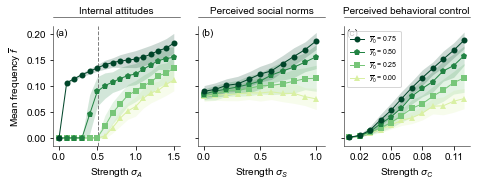

In [6]:
# PLOT FIGURE

# set labels and plot ranges
labels = [r'$\overline{y}_0=%.2f$' % _ for _ in mean_y0]
xticks = [[0, 0.5, 1, 1.5],[0, 0.5, 1.0],[0.02, 0.05, 0.08, 0.11]]
xlims = [[0-1.5*0.05, 1.5+1.5*0.05],
         [0-1*0.05, 1+1.5*0.05],
         [0.01-0.11*0.05, 0.12+0.11*0.05]]
xlabels = ['Strength $\sigma_A$',
           'Strength $\sigma_S$',
           'Strength $\sigma_C$']
titles = ['Internal attitudes',
          'Perceived social norms',
          'Perceived behavioral control']
    
# initialize figure
plt.figure(figsize=(6.5,2.35))

# plot data
for i, iv in enumerate(['scaleA', 'scaleS', 'scaleC']):

    data   = ddict[iv].mean(axis=2)
    errors = ddict[iv].std(axis=2) #(ddict[iv].max(axis=2)-ddict[iv].min(axis=2))/2 #
    xvals  = ranges[iv]
    print(data.shape, errors.shape, len(xvals))
    print(xvals)

    # set up subplot
    ax = plt.subplot(1,3,1+i)
    ax.text(0.02, 0.92, alphabet[i], transform=ax.transAxes)
    
    # add title
    plt.title(titles[i], fontsize=10, y=1.05)
    
    # underline title
    trans = ax.get_xaxis_transform()
    ax.plot(xlims[i], [1.075,1.075], color='black', lw=0.5, transform=trans, 
        clip_on=False)
    
    # plot data for subplot
    for j in range(len(mean_y0)):
        plt.fill_between(xvals, data[:,j]-errors[:,j], data[:,j]+errors[:,j],
                         color=greens[j], alpha=0.2, ec='white', lw=0)
        plt.plot(xvals, data[:,j], '^spo'[j]+'-', ms=1.5*[4,3.5,4.5,4][j],
            label=labels[j], color=greens[j], linewidth=1, zorder=10-i, 
            mec='white', mew=0.0)
        
    if i==0:
        # add vertical line at internal-attitude threshold
        scaleS = parameters['scaleS']
        shiftS = parameters['shiftS']
        threshold = -shiftS*scaleS/(alow+n*(ahigh-alow)/(n+1))
        plt.axvline(threshold, color='gray', ls='--', lw=1)
        
    if i==2:
        # add legend
        handles, labels = ax.get_legend_handles_labels()
        plt.legend(handles[::-1], labels[::-1], ncol=1, loc=0, 
            columnspacing=0.0, labelspacing=0.15, fontsize=7, 
            bbox_to_anchor=(0.48,0.46))

    plt.xlim(xlims[i])
    plt.ylim([-0.015,0.215])
    ax.set_xticks(xticks[i])
    ax.set_yticks(np.arange(0,0.21,0.05))

    plt.xlabel(xlabels[i])
    
    if i==0:
        plt.ylabel(r'Mean frequency $\overline{f}$')
    else:
        ax.set_yticklabels([])

plt.subplots_adjust(wspace=0.15, left=0.1, bottom=0.28, top=0.99, right=0.99)

# Get the current date-time string
current_datetime = datetime.now()
dts = current_datetime.strftime("%Y-%m-%d_%H.%M.%S")

# save figure with current date and time
plt.savefig('figures/figure-4_'+dts+'.pdf', bbox_inches="tight")